Bert-Encoder

In [ ]:
!pip -q install datasets transformers accelerate evaluate rouge_score sentencepiece

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.4 MB/s eta 0:00:00


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from datasets import load_dataset
import evaluate

from transformers import (
    AutoTokenizer,
    EncoderDecoderModel,
    DataCollatorForSeq2Seq,
    TrainingArguments,
    Trainer,
    set_seed,
)

In [ ]:
from datasets import load_dataset

raw = load_dataset("knkarthick/samsum")
raw

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

validation.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/14731 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/818 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/819 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 14731
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 818
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 819
    })
})

In [ ]:
set_seed(42)

from google.colab import drive
drive.mount("/content/drive")

CHECKPOINT_DIR = "/content/drive/MyDrive/samsum_ed_checkpoints"

Mounted at /content/drive


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

assert torch.cuda.is_available(), "GPU is not enabled. Go to Runtime, Change runtime type, select GPU."
print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [ ]:
raw = load_dataset("knkarthick/samsum")  # train, validation, test
raw

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 14731
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 818
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 819
    })
})

In [ ]:
print("Splits:", raw)
print("Columns:", raw["train"].column_names)

ex = raw["train"][0]
print("\nDIALOGUE:\n", ex["dialogue"])
print("\nREFERENCE SUMMARY:\n", ex["summary"])

Splits: DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 14731
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 818
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 819
    })
})
Columns: ['id', 'dialogue', 'summary']

DIALOGUE:
 Amanda: I baked  cookies. Do you want some?
Jerry: Sure!
Amanda: I'll bring you tomorrow :-)

REFERENCE SUMMARY:
 Amanda baked cookies and will bring Jerry some tomorrow.


Train size: 14731
Avg dialogue words: 93
Avg summary words: 20


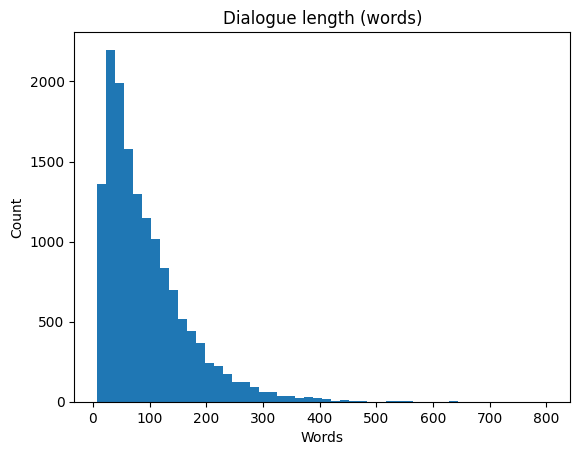

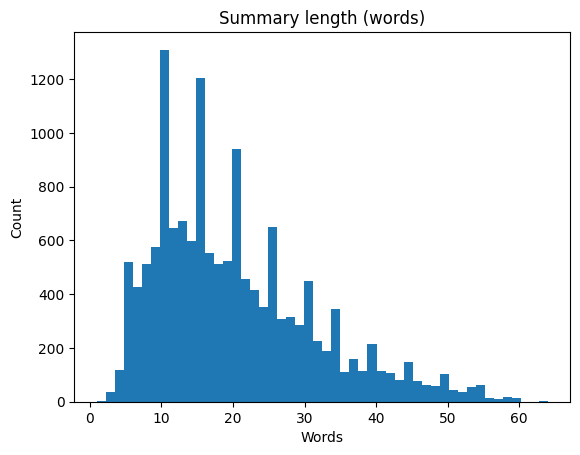

In [ ]:
def text_len_words(s):
    return len(s.split())

train = raw["train"]

dialogue_words = [text_len_words(x) for x in train["dialogue"]]
summary_words = [text_len_words(x) for x in train["summary"]]

print("Train size:", len(train))
print("Avg dialogue words:", int(np.mean(dialogue_words)))
print("Avg summary words:", int(np.mean(summary_words)))

plt.figure()
plt.hist(dialogue_words, bins=50)
plt.title("Dialogue length (words)")
plt.xlabel("Words")
plt.ylabel("Count")
plt.show()

plt.figure()
plt.hist(summary_words, bins=50)
plt.title("Summary length (words)")
plt.xlabel("Words")
plt.ylabel("Count")
plt.show()

In [ ]:
max_input_len = 256
max_target_len = 64

encoder_name = "bert-base-uncased"
decoder_name = "bert-base-uncased"

tokenizer_ed = AutoTokenizer.from_pretrained(encoder_name)

model_ed = EncoderDecoderModel.from_encoder_decoder_pretrained(
    encoder_name,
    decoder_name
)

model_ed.config.decoder_start_token_id = tokenizer_ed.cls_token_id
model_ed.config.eos_token_id = tokenizer_ed.sep_token_id
model_ed.config.pad_token_id = tokenizer_ed.pad_token_id

model_ed.config.decoder.is_decoder = True
model_ed.config.decoder.add_cross_attention = True

# Explicitly set generation parameters in model.generation_config
model_ed.generation_config.decoder_start_token_id = tokenizer_ed.cls_token_id
model_ed.generation_config.eos_token_id = tokenizer_ed.sep_token_id
model_ed.generation_config.pad_token_id = tokenizer_ed.pad_token_id
model_ed.generation_config.max_length = max_target_len # Use max_target_len defined previously
model_ed.generation_config.num_beams = 4
model_ed.generation_config.early_stopping = True

model_ed.to(device)
print("EncoderDecoderModel ready")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertLMHeadModel LOAD REPORT from: bert-base-uncased
Key                                                                | Status     | 
-------------------------------------------------------------------+------------+-
cls.seq_relationship.weight                                        | UNEXPECTED | 
bert.pooler.dense.bias                                             | UNEXPECTED | 
bert.pooler.dense.weight                                           | UNEXPECTED | 
cls.seq_relationship.bias                                          | UNEXPECTED | 
bert.encoder.layer.{0...11}.crossattention.self.key.weight         | MISSING    | 
bert.encoder.layer.{0...11}.crossattention.output.LayerNorm.bias   | MISSING    | 
bert.encoder.layer.{0...11}.crossattention.output.dense.bias       | MISSING    | 
bert.encoder.layer.{0...11}.crossattention.output.dense.weight     | MISSING    | 
bert.encoder.layer.{0...11}.crossattention.self.value.bias         | MISSING    | 
bert.encoder.layer.{0...11}.crossat

EncoderDecoderModel ready


In [ ]:
max_input_len = 256
max_target_len = 64

def preprocess_ed(batch):
    inputs = tokenizer_ed(
        batch["dialogue"],
        truncation=True,
        padding="max_length",
        max_length=max_input_len
    )
    labels = tokenizer_ed(
        batch["summary"],
        truncation=True,
        padding="max_length",
        max_length=max_target_len
    )
    inputs["labels"] = labels["input_ids"]
    return inputs

tokenized_ed = raw.map(
    preprocess_ed,
    batched=True,
    remove_columns=raw["train"].column_names
)

tokenized_ed

Map:   0%|          | 0/14731 [00:00<?, ? examples/s]

Map:   0%|          | 0/818 [00:00<?, ? examples/s]

Map:   0%|          | 0/819 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 14731
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 818
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 819
    })
})

In [ ]:
rouge = evaluate.load("rouge")

data_collator_ed = DataCollatorForSeq2Seq(
    tokenizer=tokenizer_ed,
    model=model_ed,
    padding=True
)

def compute_metrics_ed(eval_pred):
    predictions, labels = eval_pred
    if isinstance(predictions, tuple):
        predictions = predictions[0]

    # Convert predictions (logits) to token IDs
    if isinstance(predictions, torch.Tensor):
        predictions = predictions.detach().cpu().numpy()
    predictions_ids = np.argmax(predictions, axis=-1).tolist() # Convert to list of lists

    pred_text = tokenizer_ed.batch_decode(predictions_ids, skip_special_tokens=True)

    # Process labels
    labels_ids = np.where(labels != -100, labels, tokenizer_ed.pad_token_id).tolist() # Convert to list of lists
    label_text = tokenizer_ed.batch_decode(labels_ids, skip_special_tokens=True)

    scores = rouge.compute(predictions=pred_text, references=label_text)
    return {
        "rouge1": scores["rouge1"],
        "rouge2": scores["rouge2"],
        "rougeL": scores["rougeL"],
    }

In [ ]:
def summarize_ed(dialogue, max_len=64, beams=4):
    model_ed.eval()
    inputs = tokenizer_ed(
        dialogue,
        return_tensors="pt",
        truncation=True,
        max_length=max_input_len
    ).to(device)

    with torch.no_grad():
        out_ids = model_ed.generate(
            **inputs,
            max_length=max_len,
            num_beams=beams
        )
    return tokenizer_ed.decode(out_ids[0], skip_special_tokens=True)

In [ ]:
ed_args = TrainingArguments(
    output_dir=CHECKPOINT_DIR,

    # evaluation_strategy="steps", # Removed as it causes an error
    # eval_steps=1000, # Removed as it's related to evaluation_strategy

    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,

    logging_strategy="steps",
    logging_steps=100,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=1, # Further reduced to 1 to alleviate OutOfMemoryError

    learning_rate=5e-5,
    num_train_epochs=1,
    weight_decay=0.01,

    # predict_with_generate=True, # Removed as it causes an error
    fp16=torch.cuda.is_available(),
    report_to="none"
)

train_real = tokenized_ed["train"].select(range(8000))
val_real = tokenized_ed["validation"].select(range(50)) # Reduced validation set size for evaluation

trainer_ed = Trainer(
    model=model_ed,
    args=ed_args,
    train_dataset=train_real,
    eval_dataset=val_real,
    # tokenizer=tokenizer_ed, # Removed as it causes an error
    data_collator=data_collator_ed,
    compute_metrics=compute_metrics_ed
)

print("Trainer ready")

Trainer ready


In [ ]:
#smoke test because I had trouble running my long test
train_smoke = tokenized_ed["train"].select(range(200))
val_smoke = tokenized_ed["validation"].select(range(50))

trainer_smoke = Trainer(
    model=model_ed,
    args=ed_args,
    train_dataset=train_smoke,
    eval_dataset=val_smoke,
    # tokenizer=tokenizer_ed,
    data_collator=data_collator_ed,
    compute_metrics=compute_metrics_ed
)

trainer_smoke.train()
print(trainer_smoke.evaluate())

print("Sample output:")
print(summarize_ed(raw["validation"][0]["dialogue"]))

/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:445: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:445: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


{'eval_loss': 2.774423837661743, 'eval_rouge1': 0.0, 'eval_rouge2': 0.0, 'eval_rougeL': 0.0, 'eval_runtime': 6.4235, 'eval_samples_per_second': 7.784, 'eval_steps_per_second': 7.784, 'epoch': 1.0}
Sample output:
.. the............................................................


In [ ]:
trainer_ed.train()
ed_results = trainer_ed.evaluate()
ed_results

Step,Training Loss
100,2.595837
200,2.132889
300,2.071158
400,1.908353
500,1.861415
600,1.786690
700,1.915138
800,1.709374
900,1.720542
1000,1.796829


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:445: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:445: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:445: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:445: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


{'eval_loss': 1.204708218574524,
 'eval_rouge1': 0.3513654875090867,
 'eval_rouge2': 0.07677571054382336,
 'eval_rougeL': 0.2984249296444529,
 'eval_runtime': 2.5082,
 'eval_samples_per_second': 19.934,
 'eval_steps_per_second': 19.934,
 'epoch': 1.0}

In [ ]:
FINAL_DIR = "/content/drive/MyDrive/samsum_ed_final"
trainer_ed.save_model(FINAL_DIR)
tokenizer_ed.save_pretrained(FINAL_DIR)
print("Saved final model to:", FINAL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved final model to: /content/drive/MyDrive/samsum_ed_final


In [ ]:
def show_samples(n=3, split="test"):
    ds = raw[split].select(range(n))
    for i, item in enumerate(ds):
        print("\n" + "="*60)
        print("Sample", i)
        print("\nDIALOGUE:\n", item["dialogue"])
        print("\nREFERENCE:\n", item["summary"])
        print("\nPREDICTION:\n", summarize_ed(item["dialogue"]))

show_samples(n=3, split="test")


Sample 0

DIALOGUE:
 Hannah: Hey, do you have Betty's number?
Amanda: Lemme check
Hannah: <file_gif>
Amanda: Sorry, can't find it.
Amanda: Ask Larry
Amanda: He called her last time we were at the park together
Hannah: I don't know him well
Hannah: <file_gif>
Amanda: Don't be shy, he's very nice
Hannah: If you say so..
Hannah: I'd rather you texted him
Amanda: Just text him 🙂
Hannah: Urgh.. Alright
Hannah: Bye
Amanda: Bye bye

REFERENCE:
 Hannah needs Betty's number but Amanda doesn't have it. She needs to contact Larry.

PREDICTION:
 amanda and amanda are going to meet at the restaurant. amanda will call amanda.

Sample 1

DIALOGUE:
 Eric: MACHINE!
Rob: That's so gr8!
Eric: I know! And shows how Americans see Russian ;)
Rob: And it's really funny!
Eric: I know! I especially like the train part!
Rob: Hahaha! No one talks to the machine like that!
Eric: Is this his only stand-up?
Rob: Idk. I'll check.
Eric: Sure.
Rob: Turns out no! There are some of his stand-ups on youtube.
Eric: Gr8! 

In [ ]:
from transformers import EncoderDecoderModel, AutoTokenizer

MODEL_PATH = "/content/drive/MyDrive/samsum_ed_final" # Changed to FINAL_DIR for it to correctly load

model_test = EncoderDecoderModel.from_pretrained(MODEL_PATH)
tokenizer_test = AutoTokenizer.from_pretrained(MODEL_PATH)

print("Checkpoint loaded successfully")

Loading weights:   0%|          | 0/521 [00:00<?, ?it/s]

Checkpoint loaded successfully


Chat GPT - autoregressive model

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer
from transformers import DataCollatorForLanguageModeling
import gc

In [ ]:
causal_name = "gpt2"

tokenizer_clm = AutoTokenizer.from_pretrained(causal_name)
model_clm = AutoModelForCausalLM.from_pretrained(causal_name).to(device)

# GPT2 needs a pad token
tokenizer_clm.pad_token = tokenizer_clm.eos_token
model_clm.config.pad_token_id = tokenizer_clm.eos_token_id

print("Causal model ready")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Causal model ready


In [ ]:
max_prompt_len = 256
max_full_len = 384

def make_prompt(dialogue):
    return "Summarize this chat:\n" + dialogue + "\nSummary:"

def preprocess_clm(batch):
    prompts = [make_prompt(d) for d in batch["dialogue"]]
    targets = batch["summary"]
    full_texts = [p + " " + t for p, t in zip(prompts, targets)]

    tok = tokenizer_clm(
        full_texts,
        truncation=True,
        padding="max_length",
        max_length=max_full_len
    )

    tok["labels"] = tok["input_ids"].copy()
    return tok

tokenized_clm = raw.map(
    preprocess_clm,
    batched=True,
    remove_columns=raw["train"].column_names
)

tokenized_clm

Map:   0%|          | 0/14731 [00:00<?, ? examples/s]

Map:   0%|          | 0/818 [00:00<?, ? examples/s]

Map:   0%|          | 0/819 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 14731
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 818
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 819
    })
})

In [ ]:
data_collator_clm = DataCollatorForLanguageModeling(
    tokenizer=tokenizer_clm,
    mlm=False
)

In [ ]:
CLM_CHECKPOINT_DIR = "/content/drive/MyDrive/samsum_clm_checkpoints"

clm_args = TrainingArguments(
    output_dir=CLM_CHECKPOINT_DIR,

    save_strategy="steps",
    save_steps=1000,
    save_total_limit=2,

    logging_strategy="steps",
    logging_steps=200,


    per_device_train_batch_size=2,
    gradient_accumulation_steps=2,

    learning_rate=5e-5,
    num_train_epochs=1,
    weight_decay=0.01,

    fp16=torch.cuda.is_available(),
    report_to="none"
)

train_clm = tokenized_clm["train"].select(range(8000))

trainer_clm = Trainer(
    model=model_clm,
    args=clm_args,
    train_dataset=train_clm,
    data_collator=data_collator_clm
)

print("Causal Trainer ready")

Causal Trainer ready


In [ ]:
gc.collect()
torch.cuda.empty_cache()

train_smoke_clm = tokenized_clm["train"].select(range(200))

trainer_smoke_clm = Trainer(
    model=model_clm,
    args=clm_args,
    train_dataset=train_smoke_clm,
    data_collator=data_collator_clm
)

trainer_smoke_clm.train()
print("Smoke test done")

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Smoke test done


In [ ]:
gc.collect()
torch.cuda.empty_cache()

trainer_clm.train(resume_from_checkpoint=True)

print("Causal training done")

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Step,Training Loss
200,2.736861
400,2.729504
600,2.657632
800,2.645456
1000,2.604811
1200,2.580307
1400,2.581566
1600,2.586534
1800,2.587112
2000,2.578316


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Causal training done


In [ ]:
def summarize_clm(dialogue, max_new_tokens=80):
    model_clm.eval()
    prompt = make_prompt(dialogue)

    inputs = tokenizer_clm(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=max_prompt_len
    ).to(device)

    with torch.no_grad():
        out = model_clm.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    text = tokenizer_clm.decode(out[0], skip_special_tokens=True)

    if "Summary:" in text:
        return text.split("Summary:", 1)[1].strip()
    return text.strip()

In [ ]:
def eval_clm_subset(split="validation", n=200):
    ds = raw[split].select(range(min(n, len(raw[split]))))
    preds, refs = [], []
    for item in ds:
        preds.append(summarize_clm(item["dialogue"]))
        refs.append(item["summary"])
    return rouge.compute(predictions=preds, references=refs)

clm_scores = eval_clm_subset("validation", n=200)
clm_scores

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end gene

{'rouge1': np.float64(0.36468578789604783),
 'rouge2': np.float64(0.1413321001081814),
 'rougeL': np.float64(0.2992909391652182),
 'rougeLsum': np.float64(0.2998505816180562)}

In [ ]:
FINAL_CLM_DIR = "/content/drive/MyDrive/samsum_clm_final"

trainer_clm.save_model(FINAL_CLM_DIR)
tokenizer_clm.save_pretrained(FINAL_CLM_DIR)

print("Saved causal model to:", FINAL_CLM_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved causal model to: /content/drive/MyDrive/samsum_clm_final


In [ ]:
def show_compare(n=3, split="test"):
    ds = raw[split].select(range(n))
    for i, item in enumerate(ds):
        print("\n" + "="*60)
        print("Sample", i)
        print("\nDIALOGUE:\n", item["dialogue"])
        print("\nREFERENCE:\n", item["summary"])
        print("\nBERT EncoderDecoder:\n", summarize_ed(item["dialogue"]))
        print("\nAuto regressive CLM:\n", summarize_clm(item["dialogue"]))

show_compare(n=3, split="test")


Sample 0

DIALOGUE:
 Hannah: Hey, do you have Betty's number?
Amanda: Lemme check
Hannah: <file_gif>
Amanda: Sorry, can't find it.
Amanda: Ask Larry
Amanda: He called her last time we were at the park together
Hannah: I don't know him well
Hannah: <file_gif>
Amanda: Don't be shy, he's very nice
Hannah: If you say so..
Hannah: I'd rather you texted him
Amanda: Just text him 🙂
Hannah: Urgh.. Alright
Hannah: Bye
Amanda: Bye bye

REFERENCE:
 Hannah needs Betty's number but Amanda doesn't have it. She needs to contact Larry.


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



BERT EncoderDecoder:
 amanda and amanda are going to meet at the restaurant. amanda will call amanda.

Auto regressive CLM:
 Amanda has Betty's number. She will text Larry if she finds it.

Sample 1

DIALOGUE:
 Eric: MACHINE!
Rob: That's so gr8!
Eric: I know! And shows how Americans see Russian ;)
Rob: And it's really funny!
Eric: I know! I especially like the train part!
Rob: Hahaha! No one talks to the machine like that!
Eric: Is this his only stand-up?
Rob: Idk. I'll check.
Eric: Sure.
Rob: Turns out no! There are some of his stand-ups on youtube.
Eric: Gr8! I'll watch them now!
Rob: Me too!
Eric: MACHINE!
Rob: MACHINE!
Eric: TTYL?
Rob: Sure :)

REFERENCE:
 Eric and Rob are going to watch a stand-up on youtube.


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



BERT EncoderDecoder:
 rob and rob are going to the cinema together. rob is not sure how to do it.

Auto regressive CLM:
 Eric and Rob are going to watch a Russian stand-up. Rob will watch them now.

Sample 2

DIALOGUE:
 Lenny: Babe, can you help me with something?
Bob: Sure, what's up?
Lenny: Which one should I pick?
Bob: Send me photos
Lenny:  <file_photo>
Lenny:  <file_photo>
Lenny:  <file_photo>
Bob: I like the first ones best
Lenny: But I already have purple trousers. Does it make sense to have two pairs?
Bob: I have four black pairs :D :D
Lenny: yeah, but shouldn't I pick a different color?
Bob: what matters is what you'll give you the most outfit options
Lenny: So I guess I'll buy the first or the third pair then
Bob: Pick the best quality then
Lenny: ur right, thx
Bob: no prob :)

REFERENCE:
 Lenny can't decide which trousers to buy. Bob advised Lenny on that topic. Lenny goes with Bob's advice to pick the trousers that are of best quality.


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



BERT EncoderDecoder:
 bob is going to buy a new suit. bob is going to buy it. bob is going to buy a new one.

Auto regressive CLM:
 Bob will pick the best outfit for Lenny. Lenny will give Bob the most outfit options.


Dialogue Summarization for Group Chats using Transformers

Goal:

Acme Communications has a problem with information overload in group chats. When conversations get long users miss key details and it takes too long to catch up. The goal of this project is to build a proof of concept summarization feature that can turn a messenger style conversation into a short accurate summary.

What I built:

I built an end to end summarization pipeline using the SAMSum dataset. I trained two transformer based approaches:

A BERT based encoder decoder summarizer

An auto regressive causal language model summarizer that generates summaries token by token in a ChatGPT style way



the dataset is SAMSum which is a dialogue summarization dataset made of short messenger style chats.

Each example includes dialogue which is the conversation text & summary which is the human written summary

The dataset is split into train validation and test which allows proper model evaluation.

Before training I looked at basic text lengths for both dialogues and summaries. This helped me choose max token lengths that fit GPU memory and still captured most conversations.

Key takeaways:

Dialogues are much longer than summaries

Summaries are short and focused which makes this a compression task

Truncation is sometimes necessary which can remove context for longer chats

Preprocessing and Tokenization

For both models I used tokenization to turn text into input IDs.

For the BERT encoder decoder: Input is the dialogue, Target is the summary, and I used truncation and padding with fixed max lengths to keep training stable

For the auto regressive model: I formatted each example into a prompt plus answer style training string:

Prompt: “Summarize this chat: … Summary:”

Target: the reference summary appended after the prompt

This teaches the model to generate the summary after the word “Summary:”.



Model 1: BERT Encoder Decoder Summarizer

An encoder decoder model works in two stages:
The encoder reads the whole dialogue and builds a representation of it
The decoder generates the summary while attending to the encoder output
I used a BERT based encoder decoder setup. BERT is pre trained on large text corpora so fine tuning is faster and requires less data than training from scratch.

Why this model fits the business problem:

Group chats have multiple speakers and scattered details. Encoder decoder models are strong at compressing long inputs into short outputs which matches the summarization goal.

Model 2: Auto regressive Causal Language Model

A causal language model generates text one token at a time. It predicts the next token given everything before it. This is the same basic generation style used by ChatGPT type models.
In this project I fine tuned a small GPT style model using a prompt format so it learns to produce a summary after “Summary:”.

Why include this model:

It provides a second approach and a baseline comparison. It is also closer to how chat assistants generate text in real products.


Training Setup and Optimization

I trained on Colab GPU with checkpoint saving to Google Drive to avoid losing progress. Originally, I was having a lot of problems bevcause my runtime kept failing. Therefore, some important practical choices I made included:

I used shorter max input and target lengths to fit memory

I used smaller batch sizes when needed to prevent out of memory errors

I used checkpoints so training could resume after disconnects


Evaluation

I evaluated summarization quality using ROUGE which measures overlap between model summaries and human summaries.

ROUGE-1 measures unigram overlap

ROUGE-2 measures bigram overlap

ROUGE-L measures longest common subsequence overlap


Results

BERT Encoder Decoder

ROUGE-1: 0.3430

ROUGE-2: 0.0793

ROUGE-L: 0.2927

Auto regressive CLM

ROUGE-1: 0.3621

ROUGE-2: 0.1405

ROUGE-L: 0.2977

ROUGE-Lsum: 0.2980

Quick interpretation:

Both models produced readable summaries. The auto regressive model scored slightly higher on this evaluation subset. That may be influenced by decoding style and the fact that the CLM score was computed on a smaller subset.


Qualitative Examples

Sample Outputs

I printed examples from the test set showing:

The original dialogue

The human reference summary

The BERT encoder decoder output

The auto regressive model output

This helps confirm real quality beyond ROUGE. Some summaries can be correct even if wording differs which ROUGE may not fully capture.

Error Analysis

Some common failure cases:

Long conversations where truncation removes key context

Pronouns and unclear references where the model loses who did what

Missing specific details like times addresses or names

Over summarizing where the model drops a key action item

In a product setting this is where human evaluation would matter.

Limitations:

Compute limits forced smaller models and fewer epochs

Truncation can remove information from long dialogues

ROUGE focuses on overlap and does not fully measure factual accuracy

Auto regressive models can sometimes hallucinate details without strong constraints

Future Work Future Improvements

If I had more time and compute I would:

Train for more epochs with early stopping

Test stronger encoder decoder models like BART or T5 as an additional comparison

Use better decoding settings and length penalties

Add human evaluation for factual accuracy and usefulness

Create structured summaries like key decisions action items and next steps

Business Value for Acme:

A summarization feature can reduce cognitive load and help users catch up faster after being offline. This improves user experience and could improve retention. It could also be a premium feature for power users and large group chats.
This prototype shows the feature is feasible and produces useful summaries with transformer models.